In [1]:
# =========================================================
# GAUSSIAN MIXTURE MODEL (GMM) CLUSTERING
# =========================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# =========================================================
# 3. SELECT IMPORTANT FEATURES
# =========================================================
# Using customer behavior features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


# =========================================================
# 4. FEATURE SCALING
# =========================================================
# Important for distance/probability calculations

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

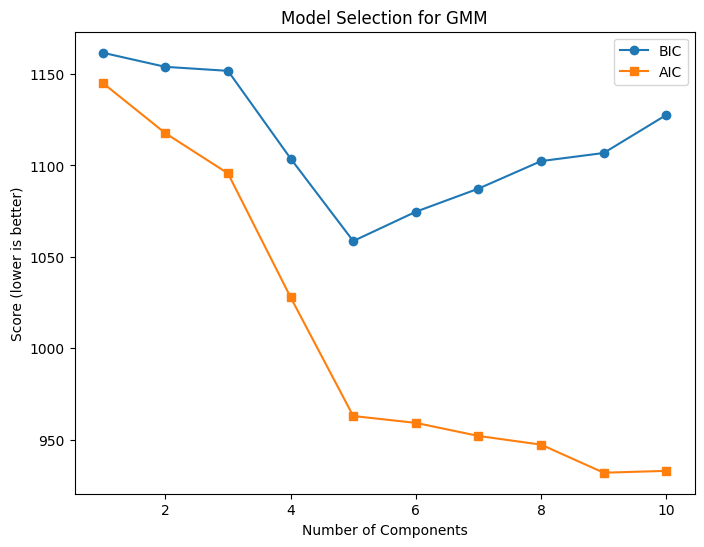

In [22]:
n_components_range = range(1,11)
bics=[]
aics=[]
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
plt.figure(figsize=(8,6))
plt.plot(n_components_range, bics, marker='o', label='BIC')
plt.plot(n_components_range, aics, marker='s', label='AIC')
plt.title('Model Selection for GMM')
plt.xlabel('Number of Components')
plt.ylabel('Score (lower is better)')
plt.legend()
plt.show()

In [23]:
# =========================================================
# 5. TRAIN GMM MODEL
# =========================================================
# From the above diagram lowest BIC score shows 5, so no of natureal group exists in this dataset is 5
gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

In [24]:
# =========================================================
# 6. PREDICT CLUSTERS
# =========================================================
# Predicting clusters y
clusters = gmm.predict(X_scaled)

df['Cluster'] = clusters

In [25]:
# =========================================================
# 7. CLUSTER PROBABILITIES
# =========================================================
# Probability of each data point belonging to clusters

probabilities = gmm.predict_proba(X_scaled)
print("\n Cluster Probabilities:")
print(probabilities[:5])


 Cluster Probabilities:
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [26]:
# =========================================================
# 8. EVALUATE MODEL
# =========================================================
score= silhouette_score(X_scaled, clusters)
print("\n silhouette score:", round(score,4)) # rounds the score to 4 decimal points


 silhouette score: 0.5537


In [12]:
#Range: -1 to +1
#Meaning:
#+1 → Perfect clustering (points are tightly grouped and well separated).
#~0.7–1.0 → Very strong clustering.
#~0.5–0.7 → Good clustering, reasonably well separated.
#~0.25–0.5 → Average clustering, some overlap.
#<0.25 → Poor clustering, clusters may not be meaningful.
#Negative → Wrong assignments (points closer to other clusters than their own).

In [27]:
# =========================================================
# 9. CLUSTER COUNTS
# =========================================================
print("\nCluster Counts:")
print(df['Cluster'].value_counts())


Cluster Counts:
Cluster
0    84
1    39
3    33
4    23
2    21
Name: count, dtype: int64


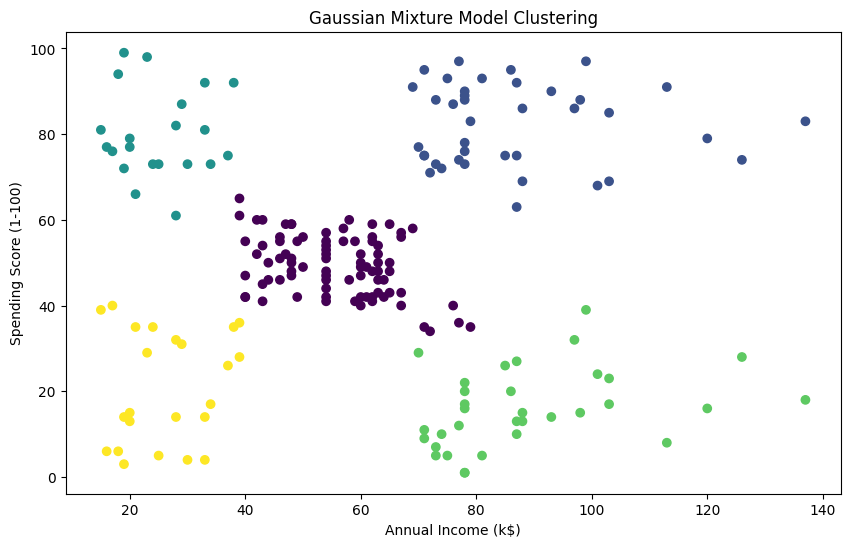


Clustered dataset saved successfully.


In [28]:
# =========================================================
# 10. VISUALIZE CLUSTERS
# =========================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Gaussian Mixture Model Clustering")

plt.show()


# =========================================================
# 11. SAVE OUTPUT
# =========================================================

df.to_csv("Mall_Customers_GMM_Clustered.csv", index=False)

print("\nClustered dataset saved successfully.")